# Readmission Risk — Experiment Notebook

In [1]:

# pip install -r requirements.txt

In [2]:
# from src.config import print_experiment_config
# print_experiment_config()

In [3]:
import pandas as pd
import numpy as np
from src.config import RAW_DATA_PATH, LABEL_COL, ALL_NUMERIC, ALL_CATEGORICAL
from src.preprocess import clean_data
from src.eda import (
    missing_data_stats, check_duplicates, target_distribution,
    numeric_summary, categorical_summary,
    feature_correlations, mutual_info_ranking, bivariate_target,
)

## Step 1 — Load & Clean

In [4]:
df = pd.read_csv(RAW_DATA_PATH)
df = df.replace("?", np.nan)
print("=== After fill_nan() ===")
missing_data_stats(df)

=== After fill_nan() ===
Rows: 101,766  |  Columns: 50
weight                      96.9
max_glu_serum               94.7
A1Cresult                   83.3
medical_specialty           49.1
payer_code                  39.6
race                         2.2
diag_3                       1.4
diag_2                       0.4
encounter_id                 0.0
troglitazone                 0.0
glyburide                    0.0
tolbutamide                  0.0
pioglitazone                 0.0
rosiglitazone                0.0
acarbose                     0.0
miglitol                     0.0
citoglipton                  0.0
tolazamide                   0.0
examide                      0.0
acetohexamide                0.0
insulin                      0.0
glyburide-metformin          0.0
glipizide-metformin          0.0
glimepiride-pioglitazone     0.0
metformin-rosiglitazone      0.0
metformin-pioglitazone       0.0
change                       0.0
diabetesMed                  0.0
glipizide            

Some features like `weight`, `medical_speciality`, and `payer_code` seem to be extremely sparse/missing, will need to evaluate if they are useful for our model. Features like `A1Cresult` and `max_glu_serum` have a large amount of missingness, but still could be meaningful as the ordering of the test could signal something to do with readmission, we keep these but handle the missing NaN values as "None". XGboost will treat this as a seperate category.

In [5]:
print(clean_data.__doc__)
df = clean_data(df)

print("=== After clean_data() ===")
missing_data_stats(df)


Domain-specific NaN handling:
  - A1Cresult, max_glu_serum: NaN -> "None" (test not ordered, not missing)
  - Everything else: left as NaN for XGBoost sparsity-aware splitting

Casts categorical columns to pandas 'category' dtype
(required for XGBoost enable_categorical=True).

=== After clean_data() ===
Rows: 101,766  |  Columns: 50
weight                      96.9
medical_specialty           49.1
payer_code                  39.6
race                         2.2
diag_3                       1.4
diag_2                       0.4
encounter_id                 0.0
tolazamide                   0.0
glipizide                    0.0
glyburide                    0.0
tolbutamide                  0.0
pioglitazone                 0.0
rosiglitazone                0.0
acarbose                     0.0
miglitol                     0.0
troglitazone                 0.0
citoglipton                  0.0
examide                      0.0
glimepiride                  0.0
insulin                      0.0
gly

## Step 2 — Exploratory Data Analysis

In [6]:
# 2a. Structure

# TODO: Handle repeated patient_nbrs
check_duplicates(df, id_col="patient_nbr")

Unique patient_nbr: 71,518 / 101,766


In [7]:
# 2b. Target
target_distribution(df)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

<30 rate: 11.2%


In [8]:
# 2c. Univariate — numeric
print(numeric_summary.__doc__)
print("\n")
numeric_summary(df, ALL_NUMERIC)


Standard statistics for numeric features.
describe() gives count, mean, std, min, quartiles, max.
Skewness tells you how lopsided the distribution is:
  0 = symmetric, positive = long right tail, negative = long left tail.


                       count   mean    std  min   25%   50%   75%    max
time_in_hospital    101766.0   4.40   2.99  1.0   2.0   4.0   6.0   14.0
num_lab_procedures  101766.0  43.10  19.67  1.0  31.0  44.0  57.0  132.0
num_procedures      101766.0   1.34   1.71  0.0   0.0   1.0   2.0    6.0
num_medications     101766.0  16.02   8.13  1.0  10.0  15.0  20.0   81.0
number_outpatient   101766.0   0.37   1.27  0.0   0.0   0.0   0.0   42.0
number_emergency    101766.0   0.20   0.93  0.0   0.0   0.0   0.0   76.0
number_inpatient    101766.0   0.64   1.26  0.0   0.0   0.0   1.0   21.0
number_diagnoses    101766.0   7.42   1.93  1.0   6.0   8.0   9.0   16.0

Skewness:
time_in_hospital       1.13
num_lab_procedures    -0.24
num_procedures         1.32
num_medications       

**Numeric features — we should keep all of them** 
- No redundancy between them (correlation heatmap confirmed no high-correlated pairs). Since the Pearson's r showed no correlation b/w these numerical values we don't have to drop any one of them to explain the others. 
- No transformations needed — tree-based models don't care about skewness/outliers since they split on thresholds, not distances.

- **`number_emergency`, `number_outpatient`, `number_inpatient`**: Most patients have 0 for all three, the rare patients with high counts are the signal. These three together capture "healthcare utilization history" and are strong candidates for a combined engineered feature.
- **`number_inpatient`**: Strongest single MI predictor (0.0112). Prior hospitalization is the clearest readmission signal.
- **`time_in_hospital`**: Captures current encounter severity. Longer stays suggest sicker patients.
- **`num_medications`**: Reflects treatment complexity. Most patients are on 10–20 meds, which is typical for a diabetic population.
- **`num_lab_procedures`**: Most evenly distributed feature. Describes diagnostic intensity during the stay.
- **`num_procedures`**: Most patients had 0–2 procedures. Low MI individually but no reason to drop.
- **`number_diagnoses`**: Measures comorbidity burden, more diagnoses = sicker patient. Ranked #3 in MI (0.0083).

We believe we can keep these features and tweak regularization params to ensure we are not overfitting on noise. 

In [9]:
# 2d. Univariate — categorical
print(categorical_summary.__doc__)
categorical_summary(df, ALL_CATEGORICAL)


Value counts for each categorical feature.
Also scans ALL columns in df for zero-variance (only 1 unique value)
using df[c].nunique() <= 1
— these are useless and should be dropped.

Zero-variance (drop): ['examide', 'citoglipton']


race (5 unique)
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641

gender (3 unique)
gender
Female             54708
Male               47055
Unknown/Invalid        3

age (10 unique)
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161

weight (9 unique)
weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3

admission_type_id (8 unique)
admission_type_id
1    53990
3    18869
2    1

**Findings from Univariate Categorical Features**

- **Zero-variance (confirmed drop):** For features `examide` and `citoglipton`every single row is "No." No information at all so we add to `EDA_DROP`

- **Near-zero-variance (drop these as well):** These medications are 99.9%+ "No" with negligible non-"No" counts:
`acetohexamide`, `troglitazone`, `glimepiride-pioglitazone`, `metformin-rosiglitazone`, `metformin-pioglitazone`, `glipizide-metformin`, `tolbutamide`, `tolazamide`, `miglitol`, `chlorpropamide`. Add to `EDA_DROP`

- **Medications with enough variation to be useful:**
`insulin`: The standout — 47,383 "No", 30,849 "Steady", 12,218 "Down", 11,316 "Up." Nearly half the patients are on insulin, and changes are common. This has the most informative distribution of any medication. The remaining useful meds are:
`metformin`, `glipizide`, `glyburide`, `pioglitazone`, `rosiglitazone`, `glimepiride`.

- **Binary treatment flags:**
`change`: roughly 50/50 split. Whether any medication was changed during the stay — well-balanced and could be informative.
`diabetesMed`: approx 77% of patients are on diabetes medication, which makes sense for a diabetic population.

- **ID-encoded columns:**
`admission_type_id` (8 unique): Over half are code 1 (emergency). Useful — emergency vs elective admissions likely have different readmission patterns. Keep this for now.
`discharge_disposition_id` (26 unique): ~60% discharged to home. Where a patient goes after discharge (home vs rehab vs skilled nursing) is clinically one of the strongest readmission predictors. Keep this for now.
`admission_source_id` (17 unique): ~56% are code 7 (ER referral). Referral source can indicate severity — ER arrivals vs physician referrals vs transfers have different risk profiles. Keep but some rare codes (<10 obs) may just be noise.

- **High-cardinality columns:**
`diag_1/2/3` (700+ unique each): Raw ICD-9 codes. The top codes map to recognizable conditions — heart failure, coronary artery disease, pneumonia, chest pain. But most codes appear few times, so the model won't have enough examples to learn. Grouping into ~20 clinical categories (e.g. all 250.* codes into "diabetes", all 428.* into "heart failure") could help because [XGBoost can't extrapolate to codes it hasn't seen.](https://towardsdatascience.com/why-xgboost-cant-solve-all-your-problems-b5003a62d12a/) 
If the training set has 428 but the test set has 428.1, the model treats them as completely unrelated. Grouping would let the model learn "heart failure patients get readmitted" rather than "ICD 428 patients get readmitted." Something we need to think about.
`medical_specialty` (72 unique, ~49% NaN): The top specialties make sense — internal medicine, emergency/trauma, family practice, cardiology. Around 40 specialties have fewer than 50 patients, which is probably too few for the model to learn meaningful patterns from. Grouping these rare specialties into "Other" might reduce noise. The large NaN proportion isn't really a problem, XGBoost handles missing values natively, and the fact that specialty wasn't recorded could itself be a signal (e.g. less specialized care).

- **Lab test flags:**
`max_glu_serum` (~5% tested): Very sparse. When a glucose serum test is ordered, it usually indicates concern about glycemic control. The "None" category (test not ordered) is the dominant signal here — the decision to test matters more than the result.
`A1Cresult` (~17% tested): More coverage than glucose serum. A1C directly measures long-term blood sugar control. Elevated A1C (>7, >8) suggests poorly managed diabetes, which is clinically linked to complications and readmission. Again, "None" (test not ordered) is itself informative.



**Summary of Features and their Importance for Univariate Tests So Far (Numerical + Categorical)**

**Definitely keep:**
`number_inpatient`, `number_emergency`, `number_outpatient`, `number_diagnoses`, `time_in_hospital`, `num_medications`, `num_procedures`, `num_lab_procedures`, `discharge_disposition_id`, `admission_type_id`, `admission_source_id`, `diag_1`, `diag_2`, `diag_3`, `insulin`, `age`, `A1Cresult`, `max_glu_serum`, `change`, `diabetesMed`

**Maybe keep:**
`medical_specialty`, `metformin`, `glipizide`, `glyburide`, `pioglitazone`, `rosiglitazone`, `glimepiride`, `payer_code`, `race`, `gender`, `weight`, `repaglinide`, `nateglinide`, `glyburide-metformin`, `acarbose`

**Definitely remove:**
`examide`, `citoglipton`, `acetohexamide`, `troglitazone`, `tolbutamide`, `tolazamide`, `miglitol`, `chlorpropamide`, `glipizide-metformin`, `glimepiride-pioglitazone`, `metformin-rosiglitazone`, `metformin-pioglitazone`

In [10]:
# 2e. Bivariate — features vs target (before binarization)
print(bivariate_target.__doc__)
bivariate_target(df, LABEL_COL, ALL_NUMERIC, ALL_CATEGORICAL)


Compare features against the raw 3-class target (NO, >30, <30).
Numeric: mean readmission per target class.
Categorical: readmission rate (<30d) per category value.

=== Numeric means by target ===
readmitted            <30    >30     NO
time_in_hospital     4.77   4.50   4.25
num_lab_procedures  44.23  43.84  42.38
num_procedures       1.28   1.25   1.41
num_medications     16.90  16.28  15.67
number_outpatient    0.44   0.50   0.27
number_emergency     0.36   0.28   0.11
number_inpatient     1.22   0.84   0.38
number_diagnoses     7.69   7.65   7.22

=== Readmission rate by category ===

race:
race
Caucasian          0.112906
AfricanAmerican    0.112181
Hispanic           0.104075
Asian              0.101404
Other              0.096282

gender:
gender
Female             0.112452
Male               0.110615
Unknown/Invalid    0.000000

age:
age
[20-30)     0.142426
[80-90)     0.120835
[70-80)     0.117731
[30-40)     0.112318
[60-70)     0.111284
[90-100)    0.110992
[40-50)     0.1

/Users/sairishi/Desktop/Projects/readmission-triage/src/eda.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(binary.groupby(df[col]).mean().sort_values(ascending=False).to_string())


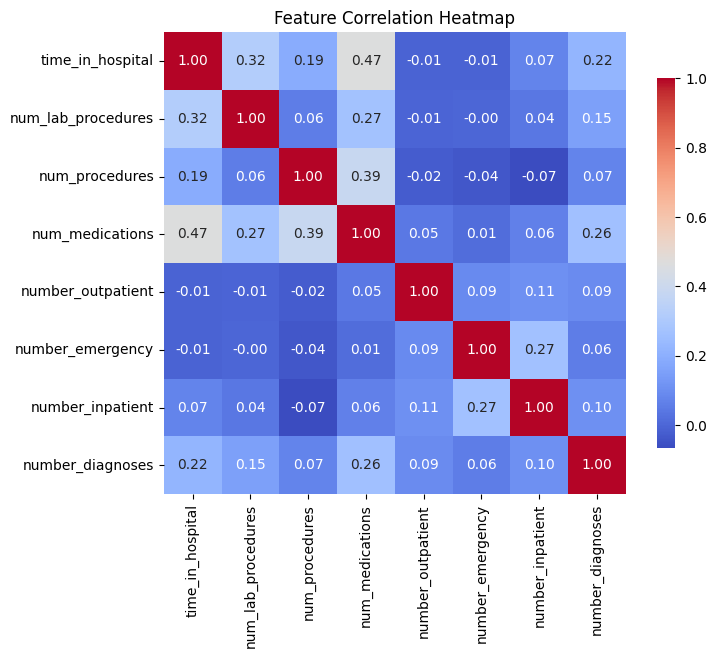

In [11]:
# 2f. Feature redundancy — numeric Pearson
feature_correlations(df, ALL_NUMERIC)

**What Does The Heatmap Tell Us?**

No pair exceeds r = 0.47, so no redundancy — each feature captures something different. The overall weak correlations also suggest the relationships in this data aren't linear, which is another reason we're going with XGBoost over something like logistic regression.

In [12]:
# 2g. Mutual Information
print(mutual_info_ranking.__doc__)
mi_scores = mutual_info_ranking(df)


Rank features by how much they tell you about the target (readmission).

Mutual Information (MI) measures dependency between a feature and the target.
MI = 0 means the feature tells you nothing. Higher = more useful.
Unlike Pearson correlation, MI catches non-linear relationships too.

number_inpatient            0.0112
diag_1                      0.0085
number_diagnoses            0.0083
diag_3                      0.0076
discharge_disposition_id    0.0076
diag_2                      0.0071
time_in_hospital            0.0039
number_emergency            0.0039
medical_specialty           0.0018
number_outpatient           0.0017
num_medications             0.0015
num_procedures              0.0014
insulin                     0.0009
age                         0.0006
payer_code                  0.0005
diabetesMed                 0.0004
metformin                   0.0003
admission_source_id         0.0003
change                      0.0002
A1Cresult                   0.0002
admission_ty

Bivariate and MI results mostly confirm what we saw in the univariate analysis.

The utilization features dominate — `number_inpatient` averages 1.22 for readmitted vs 0.38 for non-readmitted, and `number_emergency` shows a similar 3x gap. These are the top MI features too. The rest of the numerics show smaller but consistent separation across target classes so we're keeping all 8.

For categoricals, `discharge_disposition_id` stands out with some codes hitting 27-37% readmission vs 9% for discharged-to-home. `insulin` is the only medication with both a real bivariate spread (13.9% Down vs 10.0% No) and nonzero MI. `age` has a non-obvious pattern where [20-30) actually has the highest readmission rate at 14.2%. `A1Cresult` and `max_glu_serum` show subtle signal — interestingly "None" (test not ordered) has a higher rate than normal results for A1C, so the decision to test itself seems to matter.

The "maybe keep" medications (`metformin`, `glipizide`, `glyburide`, etc.) all individually round to MI = 0.0000 but show some bivariate spread when doses change. Keeping them for now since they could feed a combined `med_change_count` feature later. `race` and `gender` show basically no separation but we'll keep them for fairness analysis. `medical_specialty` has wide variation but a lot of it is noise from tiny samples (Resident = 50% readmission rate but only 2 patients). Still worth keeping since the top specialties have enough volume.

Moving `weight` to definitely remove — 97% missing, MI = 0, and the bivariate rates are based on samples so small they're meaningless (e.g. [0-25) shows 16.7% but that's 48 patients).

The near-zero-variance medications we flagged are all confirmed at MI = 0.0000 with bivariate rates identical to baseline or based on single-digit samples. Adding all of them plus `weight` to `EDA_DROP`.

**Final Feature Decisions After Full EDA (Univariate + Bivariate + MI)**

**Definitely keep:**
`number_inpatient`, `number_emergency`, `number_outpatient`, `number_diagnoses`, `time_in_hospital`, `num_medications`, `num_procedures`, `num_lab_procedures`, `discharge_disposition_id`, `admission_type_id`, `admission_source_id`, `diag_1`, `diag_2`, `diag_3`, `insulin`, `age`, `A1Cresult`, `max_glu_serum`, `change`, `diabetesMed`

**Maybe keep (low individual signal, but no cost to include):**
`medical_specialty`, `metformin`, `glipizide`, `glyburide`, `pioglitazone`, `rosiglitazone`, `glimepiride`, `payer_code`, `race`, `gender`, `repaglinide`, `nateglinide`, `glyburide-metformin`, `acarbose`

**Definitely remove (add to `EDA_DROP`):**
`examide`, `citoglipton` — zero-variance
`acetohexamide`, `troglitazone`, `tolbutamide`, `tolazamide`, `miglitol`, `chlorpropamide`, `glipizide-metformin`, `glimepiride-pioglitazone`, `metformin-rosiglitazone`, `metformin-pioglitazone` — near-zero-variance, MI = 0,`weight` — 97% missing, MI = 0, bivariate rates based on samples too small to be useful.

## Step 3 - Feature Selection & Engineering

In [ ]:
from src.config import EDA_DROP, DROP_COLS
from src.feature_engineering import add_utilization_index, add_med_change_count, count_repeated_encounters
from src.preprocess import remove_expired_patients

# Doing ID-related feature engineering here before we drop these cols
df = count_repeated_encounters(df) # uses patient_nbr and encounter_id

# Removing rows where discharge_disposition_id indicates patient has expired
# They won't be readmitted hence leaky.
df = remove_expired_patients(df)

# Feature selection — drop IDs and EDA-flagged columns
df = df.drop(columns=[c for c in DROP_COLS + EDA_DROP if c in df.columns])
print(f"Dropped {len(DROP_COLS)} ID cols + {len(EDA_DROP)} EDA cols : {df.shape[1]} columns remaining")

# Feature engineering
df = add_utilization_index(df)
print(f"utilization_index: mean={df['utilization_index'].mean():.2f}, max={df['utilization_index'].max()}")

df = add_med_change_count(df)
print(f"med_up_count: mean={df['med_up_count'].mean():.2f}, max={df['med_up_count'].max()}")
print(f"med_down_count: mean={df['med_down_count'].mean():.2f}, max={df['med_down_count'].max()}")
print(f"med_steady_count: mean={df['med_steady_count'].mean():.2f}, max={df['med_steady_count'].max()}")

Dropped 2 ID cols + 13 EDA cols : 36 columns remaining
utilization_index: mean=1.20, max=80
med_up_count: mean=0.15, max=3
med_down_count: mean=0.14, max=3
med_steady_count: mean=0.90, max=6


## Step 4 - Train / Validation / Test Split

In [14]:
from src.config import FEATURE_COLS, LABEL_COL, NUMERIC_COLS, CATEGORICAL_COLS, RANDOM_SEED
from sklearn.model_selection import train_test_split

y = (df[LABEL_COL] == "<30").astype(int)
X = df[FEATURE_COLS]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp)

print(f"Train: {X_train.shape[0]:,} ({y_train.mean():.1%} positive)")
print(f"Val:   {X_val.shape[0]:,} ({y_val.mean():.1%} positive)")
print(f"Test:  {X_test.shape[0]:,} ({y_test.mean():.1%} positive)")

Train: 69,540 (11.4% positive)
Val:   14,901 (11.4% positive)
Test:  14,902 (11.4% positive)


## Step 5 - Baseline XGBoost

**NOTE:**
Make sure OpenMP is installed.

run:
brew install libomp (for MacOS only)

In [15]:
import yaml
import xgboost as xgb

with open("src/hparam_config.yaml", "r") as f:
    hparam_config = yaml.safe_load(f)

# Inject hyperparameter config here 
params = hparam_config["tuned_v1"]

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

# NOTE: we are only testing for two classes here. 
# <30 = 1, rest = 0.
model = xgb.XGBClassifier(
  **params,
  scale_pos_weight=neg / pos,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=1, # this parameter prints progress after every train-eval loop
)

[0]	validation_0-aucpr:0.16724
[1]	validation_0-aucpr:0.17927
[2]	validation_0-aucpr:0.18888
[3]	validation_0-aucpr:0.19293
[4]	validation_0-aucpr:0.19675
[5]	validation_0-aucpr:0.19819
[6]	validation_0-aucpr:0.20003
[7]	validation_0-aucpr:0.19788
[8]	validation_0-aucpr:0.20165
[9]	validation_0-aucpr:0.20174
[10]	validation_0-aucpr:0.20214
[11]	validation_0-aucpr:0.20333
[12]	validation_0-aucpr:0.20215
[13]	validation_0-aucpr:0.20274
[14]	validation_0-aucpr:0.20363
[15]	validation_0-aucpr:0.20446
[16]	validation_0-aucpr:0.20573
[17]	validation_0-aucpr:0.20604
[18]	validation_0-aucpr:0.20652
[19]	validation_0-aucpr:0.20681
[20]	validation_0-aucpr:0.20804
[21]	validation_0-aucpr:0.20765
[22]	validation_0-aucpr:0.20779
[23]	validation_0-aucpr:0.20843
[24]	validation_0-aucpr:0.20890
[25]	validation_0-aucpr:0.20839
[26]	validation_0-aucpr:0.20809
[27]	validation_0-aucpr:0.20930
[28]	validation_0-aucpr:0.20880
[29]	validation_0-aucpr:0.20868
[30]	validation_0-aucpr:0.20877
[31]	validation_0-

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

## Step 6 - Baseline Evaluation

In [16]:
from src.validation import evaluate_model
evaluate_model(model, X_val, y_val)

AUCPR:     0.2140
AUROC:     0.6625
Precision: 0.1847
Recall:    0.5333
Confusion: TN=9209  FP=3995  FN=792  TP=905


## Step 7 - Cross-Validation

Verify the baseline is stable across different data splits.
If the AUCPR is consistent across folds, we can trust the number and move on to resampling.

In [17]:
from src.validation import cross_validate

X_cv = pd.concat([X_train, X_val])
y_cv = pd.concat([y_train, y_val])

cross_validate(X_cv, y_cv, params)

[0]	validation_0-aucpr:0.17070
[1]	validation_0-aucpr:0.18026
[2]	validation_0-aucpr:0.18583
[3]	validation_0-aucpr:0.18877
[4]	validation_0-aucpr:0.18786
[5]	validation_0-aucpr:0.18632
[6]	validation_0-aucpr:0.18697
[7]	validation_0-aucpr:0.18754
[8]	validation_0-aucpr:0.18960
[9]	validation_0-aucpr:0.18885
[10]	validation_0-aucpr:0.18947
[11]	validation_0-aucpr:0.18965
[12]	validation_0-aucpr:0.18947
[13]	validation_0-aucpr:0.18911
[14]	validation_0-aucpr:0.19089
[15]	validation_0-aucpr:0.19065
[16]	validation_0-aucpr:0.19172
[17]	validation_0-aucpr:0.19256
[18]	validation_0-aucpr:0.19247
[19]	validation_0-aucpr:0.19220
[20]	validation_0-aucpr:0.19335
[21]	validation_0-aucpr:0.19459
[22]	validation_0-aucpr:0.19467
[23]	validation_0-aucpr:0.19482
[24]	validation_0-aucpr:0.19510
[25]	validation_0-aucpr:0.19439
[26]	validation_0-aucpr:0.19413
[27]	validation_0-aucpr:0.19408
[28]	validation_0-aucpr:0.19445
[29]	validation_0-aucpr:0.19474
[30]	validation_0-aucpr:0.19421
[31]	validation_0-

## Step 8 - Resampling w/ SMOTENC

In [18]:
from imblearn.over_sampling import SMOTENC
from src.config import CATEGORICAL_COLS, RANDOM_SEED

cat_indices = [i for i, col in enumerate(X_train.columns) if col in CATEGORICAL_COLS]

smotenc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train_res, y_train_res = smotenc.fit_resample(X_train, y_train)

In [19]:
# Training on new resampled X_train_res and y_train_res
# <30 = 1, rest = 0.
model = xgb.XGBClassifier(
  **params,
  # scale_pos_weight=neg / pos, NOTE: since we are resampling we don't use 
  # this parameter anymore
)

model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_val, y_val)],
    verbose=1, # this parameter prints progress after every train-eval loop
)

[0]	validation_0-aucpr:0.12760
[1]	validation_0-aucpr:0.16300
[2]	validation_0-aucpr:0.16717
[3]	validation_0-aucpr:0.16663
[4]	validation_0-aucpr:0.17081
[5]	validation_0-aucpr:0.16723
[6]	validation_0-aucpr:0.16880
[7]	validation_0-aucpr:0.16787
[8]	validation_0-aucpr:0.16820
[9]	validation_0-aucpr:0.16809
[10]	validation_0-aucpr:0.16583
[11]	validation_0-aucpr:0.16657
[12]	validation_0-aucpr:0.16742
[13]	validation_0-aucpr:0.16786
[14]	validation_0-aucpr:0.16746
[15]	validation_0-aucpr:0.16699
[16]	validation_0-aucpr:0.16591
[17]	validation_0-aucpr:0.16523
[18]	validation_0-aucpr:0.16491
[19]	validation_0-aucpr:0.16471
[20]	validation_0-aucpr:0.16481
[21]	validation_0-aucpr:0.16553
[22]	validation_0-aucpr:0.16507
[23]	validation_0-aucpr:0.16568
[24]	validation_0-aucpr:0.16534
[25]	validation_0-aucpr:0.16580
[26]	validation_0-aucpr:0.16585
[27]	validation_0-aucpr:0.16539
[28]	validation_0-aucpr:0.16484
[29]	validation_0-aucpr:0.16493
[30]	validation_0-aucpr:0.16483
[31]	validation_0-

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [20]:
from src.validation import evaluate_model
evaluate_model(model, X_val, y_val)

AUCPR:     0.1364
AUROC:     0.5698
Precision: 0.1445
Recall:    0.3701
Confusion: TN=9487  FP=3717  FN=1069  TP=628


**Decisions and Findings from Step 8**

- We used SMOTENC since this is the resampling technique that has in-built functionality to handle categorical values. The reason we are probably seeing our scores decline especially in the precision, recall and AUCPR metrics is due to the new synthetic noisy data introduced into the dataset. Other SMOTE (eg. SMOTEENN and KMeansSMOTE) techniques require a significant presence of numerical features which we lack in our dataset.

- We also tried to utilize a hybrid method where SMOTEENN utilizes SMOTENC as its SMOTE of choice (by passing the `smote=smotenc` paramater for the SMOTEENN class) while also using Edited Nearest Neighbors for under-sampling/de-noising. An issue arose where the SMOTEENN function required explicit handling of `NaN` values through imputation (We left `NaN` values to leverage XGBoost's sparsity aware handling).

- Now, since our dataset possesses a large amount of categorical feature one imputation strategy we looked into was KMeansImputation from scikit-learn. But we anticipated another potential issue. KMeansImputation requires for our features to be strongly related, which as demonstrated by the Mutual Information scores and the Pearson's r, isn't present in our dataset. The XGBoost model works because it leverages the diluted signal across many features using many sequential weak learners.

**Decision:**

The point of reporting this section is to show that we tried, but utimately this endeavour seemed to prove fruitless. The `scale_pos_weight` hyperparameter does a decent enough job of penalizing the misclassification of positive values. We stick to using this and disregard the SMOTENC results.

## Step 9 - Hyperparameter Tuning w/ Optuna

In [21]:
import optuna
from sklearn.metrics import average_precision_score

def objective(trial):
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()

    params = {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "enable_categorical": True,
        "random_state": RANDOM_SEED,
        "scale_pos_weight": neg / pos,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 5),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 6.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 6.0),
        "n_estimators": 500,
        "early_stopping_rounds": 50,
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=0)

    y_proba = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, y_proba)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=54) 
    )
study.optimize(objective, n_trials=100)

print(f"Best AUCPR: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

/Users/sairishi/Desktop/Projects/readmission-triage/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-10 00:35:51,933] A new study created in memory with name: no-name-bb5f201f-c722-4a27-af03-8f77f5617e2e
[I 2026-04-10 00:35:52,467] Trial 0 finished with value: 0.1953224842167911 and parameters: {'learning_rate': 0.1318530604708244, 'max_depth': 5, 'min_child_weight': 2, 'max_delta_step': 3, 'subsample': 0.5043027260043846, 'colsample_bytree': 0.9844681033597431, 'reg_alpha': 4.808287536098765, 'reg_lambda': 4.5438719316519265}. Best is trial 0 with value: 0.1953224842167911.
[I 2026-04-10 00:35:52,817] Trial 1 finished with value: 0.2011019239102717 and parameters: {'learning_rate': 0.20473044753412895, 'max_depth': 3, 'min_child_weight': 4, 'max_delta_step': 2, 'subsample': 0.59481550719

Best AUCPR: 0.2342
Best params: {'learning_rate': 0.01714689157836875, 'max_depth': 8, 'min_child_weight': 9, 'max_delta_step': 2, 'subsample': 0.9225447376440449, 'colsample_bytree': 0.5094290584890735, 'reg_alpha': 5.344365050644109, 'reg_lambda': 4.923579059919643}


In [22]:
# Retraining w/ Optuna hyperparameters

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

model = xgb.XGBClassifier(
    **study.best_params,
    objective="binary:logistic",
    eval_metric="aucpr",
    enable_categorical=True,
    n_estimators=500,
    early_stopping_rounds=50,
    random_state=RANDOM_SEED,
    scale_pos_weight=neg / pos,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=1)

[0]	validation_0-aucpr:0.18850
[1]	validation_0-aucpr:0.19426
[2]	validation_0-aucpr:0.20387
[3]	validation_0-aucpr:0.20428
[4]	validation_0-aucpr:0.20555
[5]	validation_0-aucpr:0.20517
[6]	validation_0-aucpr:0.20857
[7]	validation_0-aucpr:0.20777
[8]	validation_0-aucpr:0.20869
[9]	validation_0-aucpr:0.20850
[10]	validation_0-aucpr:0.21170
[11]	validation_0-aucpr:0.21106
[12]	validation_0-aucpr:0.21014
[13]	validation_0-aucpr:0.21222
[14]	validation_0-aucpr:0.21036
[15]	validation_0-aucpr:0.21178
[16]	validation_0-aucpr:0.21130
[17]	validation_0-aucpr:0.21089
[18]	validation_0-aucpr:0.21240
[19]	validation_0-aucpr:0.21402
[20]	validation_0-aucpr:0.21373
[21]	validation_0-aucpr:0.21414
[22]	validation_0-aucpr:0.21429
[23]	validation_0-aucpr:0.21595
[24]	validation_0-aucpr:0.21597
[25]	validation_0-aucpr:0.21598
[26]	validation_0-aucpr:0.21604
[27]	validation_0-aucpr:0.21641
[28]	validation_0-aucpr:0.21658
[29]	validation_0-aucpr:0.21766
[30]	validation_0-aucpr:0.21894
[31]	validation_0-

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5094290584890735
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

## Step 10 - Domain-Specific Threshold Tuning

- We use a slightly smaller threshold than 0.5 here.

- The reason for this is because we want to prioritize recall values
at the cost of precision. 

- For a medical dataset that hopes to catch patients at risk of readmission, this forms a **"better-safe-than-sorry"** approach
where we would prefer overshooting on the decision to run intervention
even if it means a few patients that weren't at risk were put through intervention.

In [23]:

evaluate_model(model, X_test, y_test, threshold=0.47)

AUCPR:     0.2412
AUROC:     0.6870
Precision: 0.1862
Recall:    0.6199
Confusion: TN=8608  FP=4597  FN=645  TP=1052


## Step 11 - ROC Curve & Precision-Recall Curve Display

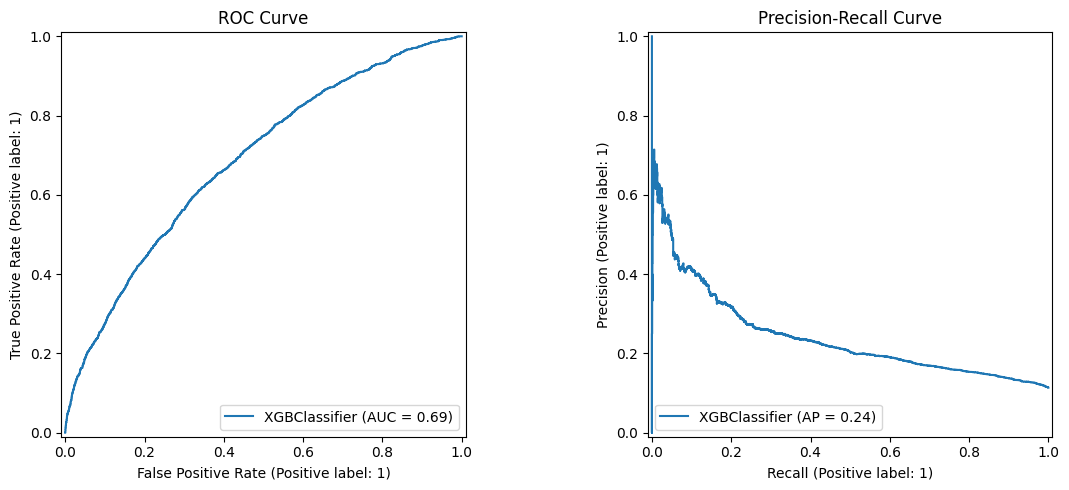

In [24]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax1)
ax1.set_title("ROC Curve")

PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax2)
ax2.set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

## Step 12 - SHapley's Additive exPlanations - Explaining Feature Importance in Black-Box models

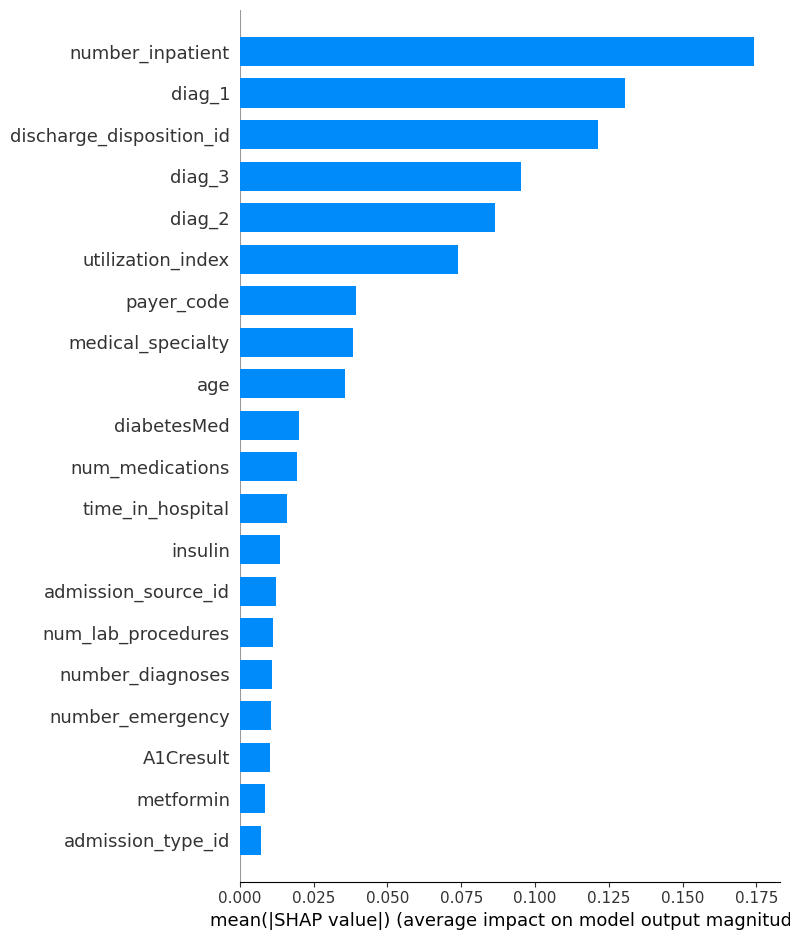

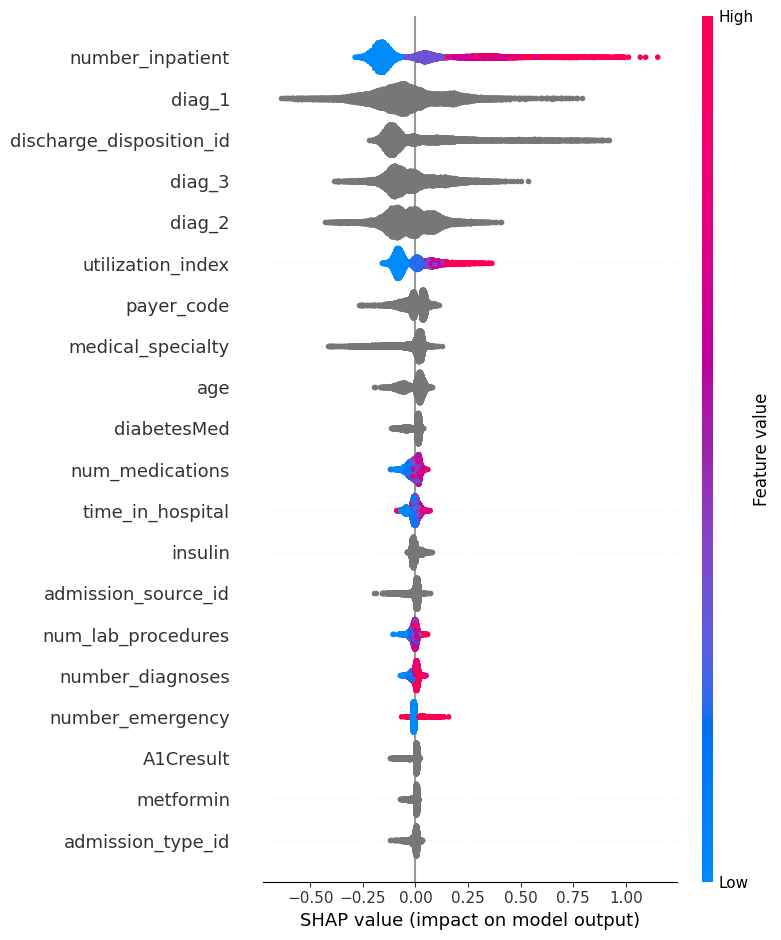

In [25]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")  # global importance
shap.summary_plot(shap_values, X_test)                    # detailed beeswarm